### Analysis

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/cleaned_superstore_data.csv')
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit', 'ship_time'],
      dtype='str')

### Question 1 : What are our total sales? 

In [2]:
df["sales"].describe()

count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: sales, dtype: float64

In [5]:
df["sales"].sum()

np.float64(2297200.8603)

#### Answer:
##### Our total sales are 2297200.8603 with a mean of 229.858, max value of 22638.48, min value of 0.444 and median of 54.49

### Question 2: How do sales change over time?

In [21]:
# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Group by year and month
df['month'] = df['order_date'].dt.to_period('M')
sales_by_month = df.groupby('month')['sales'].sum()

# Group by year
df['year'] = df['order_date'].dt.year
sales_by_year = df.groupby('year')['sales'].sum()

sales_by_month.head()


month
2014-01    14236.895
2014-02     4519.892
2014-03    55691.009
2014-04    28295.345
2014-05    23648.287
Freq: M, Name: sales, dtype: float64

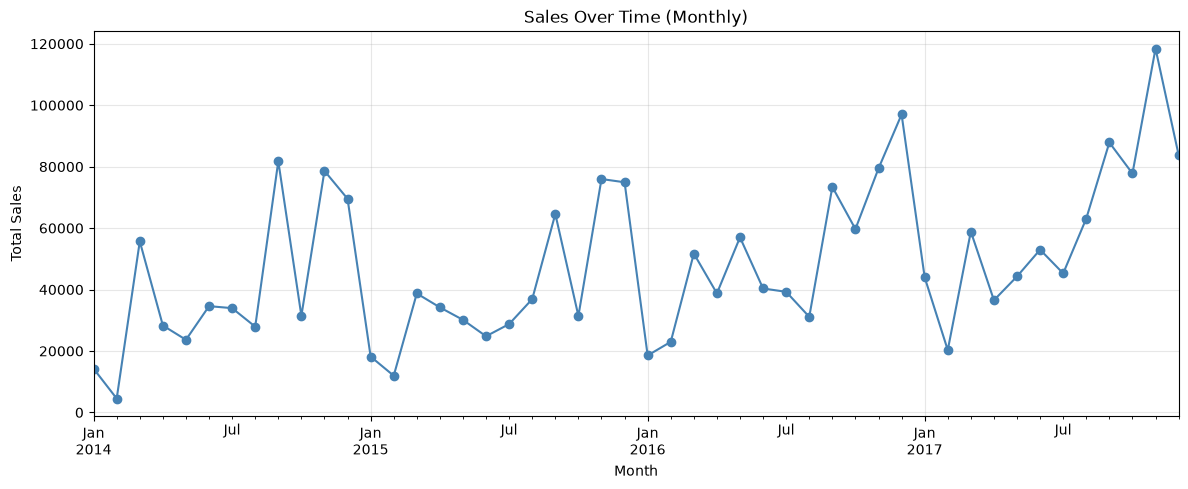

In [17]:
# Create line charts
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# Line chart by month
sales_by_month.plot(ax=axes, kind='line', marker='o', color='steelblue')
axes.set_title('Sales Over Time (Monthly)')
axes.set_xlabel('Month')
axes.set_ylabel('Total Sales')
axes.grid(True, alpha=0.3)


##### From chart we can see that the sales are increasing during the last period since 2017 with the highest peak on the November with 118447.8250. We also can see that during these years sales goes up starting from November untill December and on january the sales drop so this is a period of 2 months that sales increase. There is an unusual drop from Dectember 2016 untill February 2017

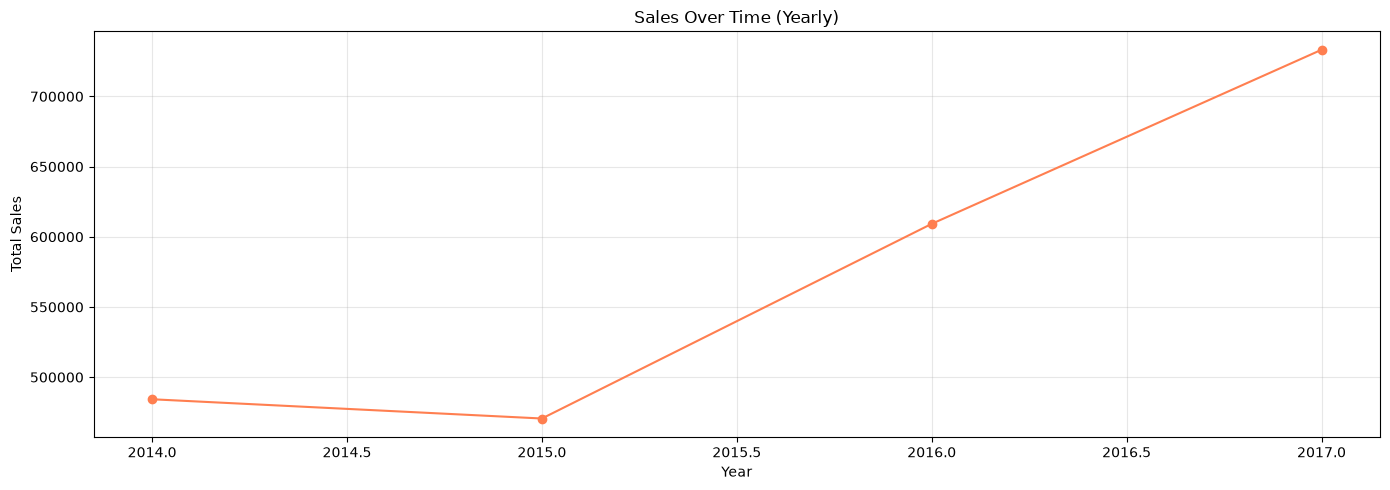

In [18]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))
# Line chart by year
sales_by_year.plot(ax=axes, kind='line', marker='o', color='coral')
axes.set_title('Sales Over Time (Yearly)')
axes.set_xlabel('Year')
axes.set_ylabel('Total Sales')
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### This chart here shows the sales during the years and as we can see here the sales are going up on the last 2 years. We can see a decrease of the sales during the first year but then during 2015-2017 the sales are increasing 

### Question 3: Which regions generate the most sales?

In [23]:
#sales by region
sales_by_region = df.groupby('region')['sales'].sum().sort_values(ascending=False)
sales_by_region.head()

region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: sales, dtype: float64

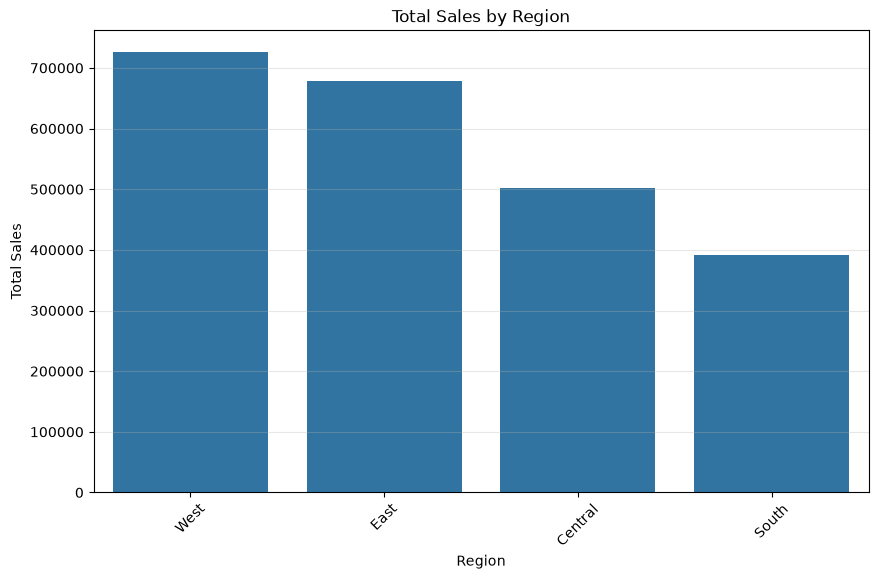

In [26]:
#Bar chart for sales by region
plt.figure(figsize=(10, 6))
plot = sns.barplot(x=sales_by_region.index, y=sales_by_region.values)
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

##### The West generates the highest sales, while the South generates the lowest. Further analysis is needed to determine whether the difference is driven by customer volume, product mix, pricing, or other factors.

### Question 4: Which states generate the most revenue?

In [32]:
#Group by state
sales_by_state = df.groupby('state')['sales'].sum().sort_values(ascending=False)
print(sales_by_state.head(10))
print(sales_by_state.tail(10))

state
california      457687.6315
new york        310876.2710
texas           170188.0458
washington      138641.2700
pennsylvania    116511.9140
florida          89473.7080
illinois         80166.1010
ohio             78258.1360
michigan         76269.6140
virginia         70636.7200
Name: sales, dtype: float64
state
new mexico              4783.522
iowa                    4579.760
idaho                   4382.486
kansas                  2914.310
district of columbia    2865.020
wyoming                 1603.136
south dakota            1315.560
maine                   1270.530
west virginia           1209.824
north dakota             919.910
Name: sales, dtype: float64


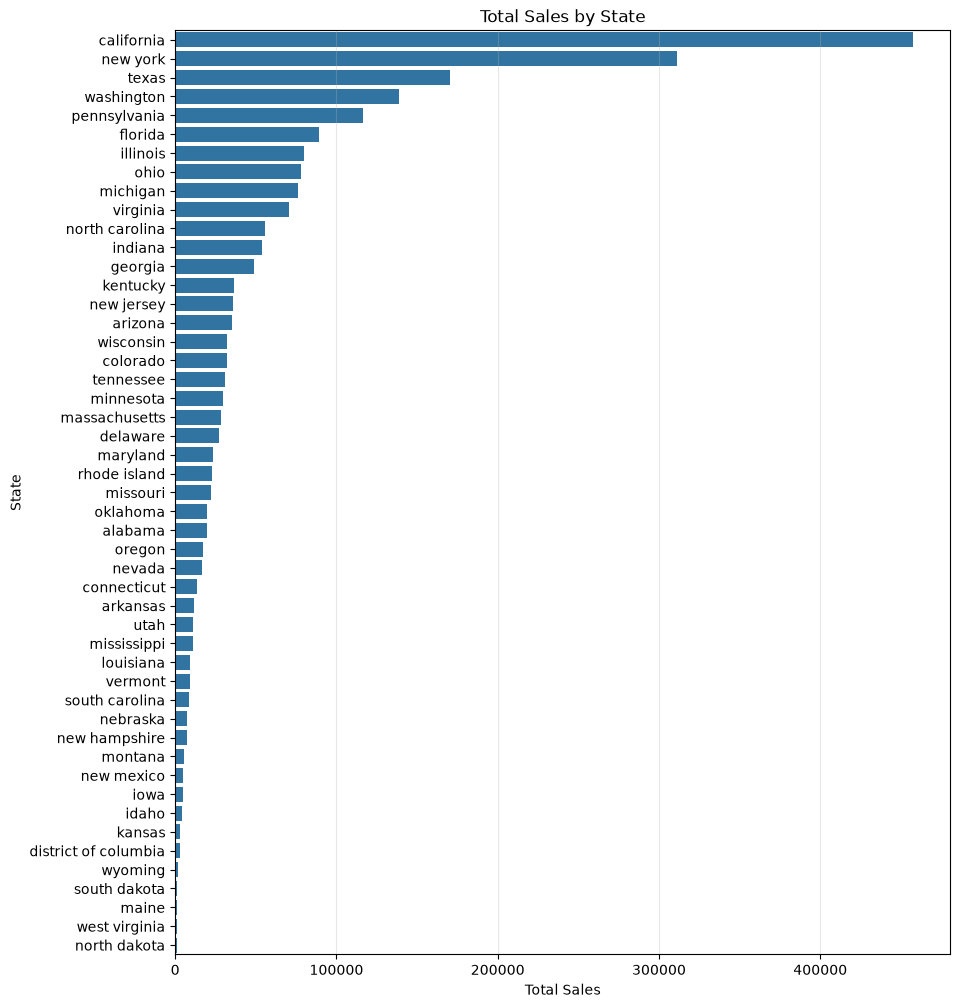

In [30]:
#Horizontal bar chart for sales by state
plt.figure(figsize=(10, 12))
plot = sns.barplot(x=sales_by_state.values, y=sales_by_state.index, )
plt.title('Total Sales by State')
plt.xlabel('Total Sales')
plt.ylabel('State')
plt.grid(axis='x', alpha=0.3)
plt.show()

##### We can see that the state with the most sales is california and with the least sales is north dakota 

### Question 5: Which customer segment generates the most revenue?

In [34]:
#Group by costumer segment
sales_by_segment = df.groupby('segment')['sales'].sum().sort_values(ascending=False)
sales_by_segment.head()

segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: sales, dtype: float64

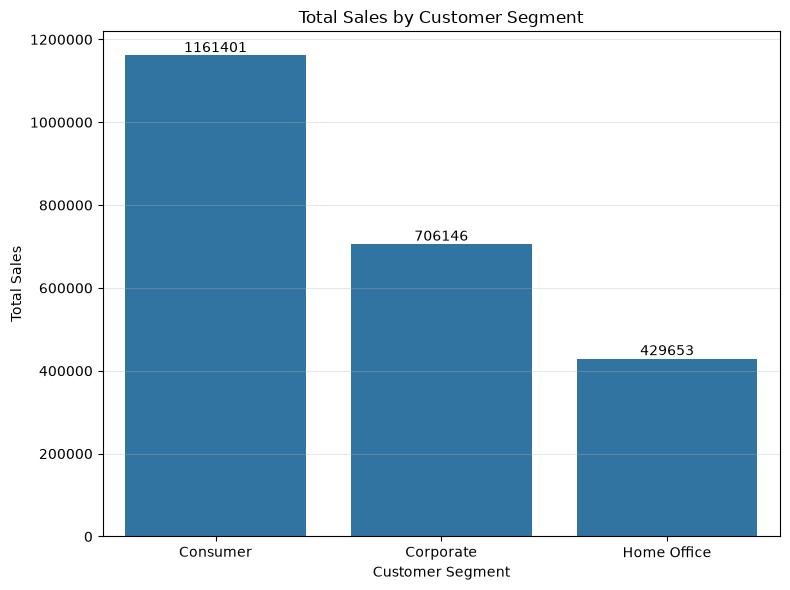

In [44]:
#Bar chart for sales by customer segment
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=sales_by_segment.index, y=sales_by_segment.values)
ax.set_title('Total Sales by Customer Segment')
ax.set_xlabel('Customer Segment')
ax.set_ylabel('Total Sales')
ax.ticklabel_format(style='plain', axis='y') # Prevent scientific notation
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

##### Costumer segment that buy the most is consumer segment.

### Question 6: Which categories generate the highest profit?

In [71]:
#Group by categories and profit
profit_by_category = df.groupby('category')['profit'].sum().sort_values(ascending=False)
profit_by_category.head()

category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: profit, dtype: float64

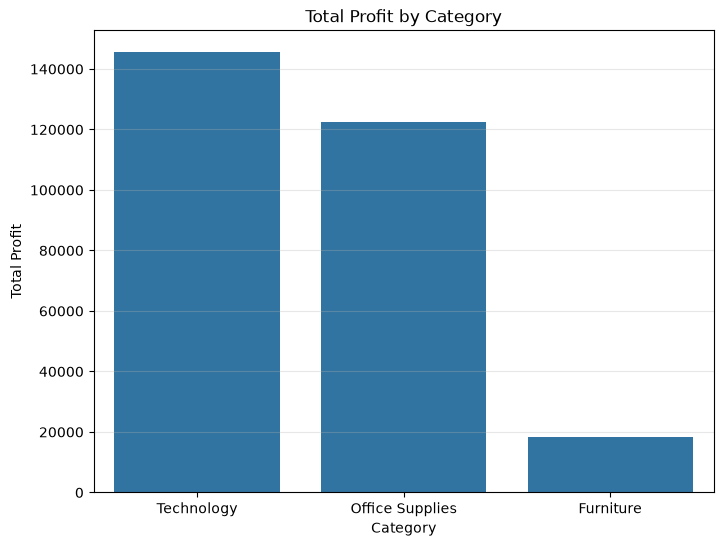

In [72]:
#Bar chart for categories and profit
plt.figure(figsize=(8, 6))
plot = sns.barplot(x=profit_by_category.index, y=profit_by_category.values)
plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.grid(axis='y', alpha=0.3)
plt.show()

##### Technology is the category with the most profit 145454.9481. Office Supplies Category is the second with 122490.8008 and furniture are the last category with a profit of 18451.2728 

### Qestion 7: Which sub-categories lose money?

In [69]:
#Group by sub-categories and profit
profit_by_sub_category = df.groupby('sub-category')['profit'].sum().sort_values(ascending=True)
profit_by_sub_category_negative = profit_by_sub_category[profit_by_sub_category < 0]
profit_by_sub_category_negative.head()

sub-category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: profit, dtype: float64

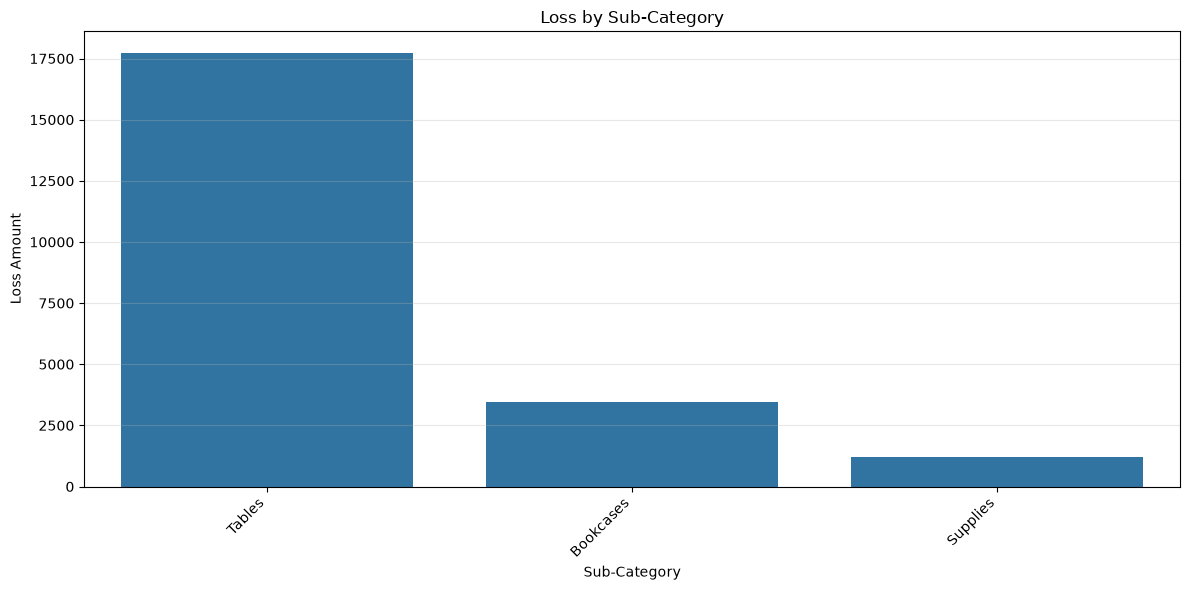

In [70]:
# bar chart for negative profit by sub-category
plt.figure(figsize=(12, 6))
sns.barplot(
    x=profit_by_sub_category_negative.index,
    y=-profit_by_sub_category_negative.values
)
plt.title('Loss by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Loss Amount')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

##### Sub-category with the most loss is Tables. This sub-category should be investigated further to determine the causes of its negative profitability before making a decision about discontinuing the category.


### Question 8: Does high sales always mean high profit?

Overall correlation between sales and profit: 0.4791
                       sales       profit
category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481


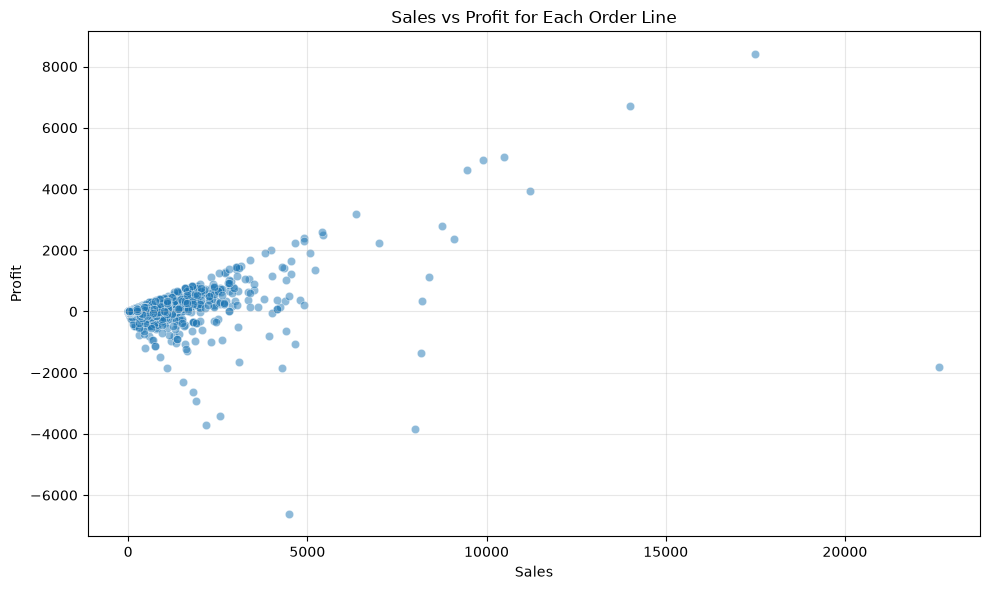

In [63]:
correlation = df['sales'].corr(df['profit'])
print(f"Overall correlation between sales and profit: {correlation:.4f}")

sales_profit_by_category = df.groupby('category')[['sales', 'profit']].sum()
print(sales_profit_by_category)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sales', y='profit', alpha=0.5)
plt.title('Sales vs Profit for Each Order Line')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##### Sales and profit show a positive relationship overall, meaning higher sales tend to be associated with higher profit. However, the relationship is not perfect, and some transactions generate negative profit despite having positive sales. This suggests that revenue alone does not guarantee profitability.

### Question 9: Who are our top costumers? 

In [66]:
#Top costumer name by sales
top_customers = df.groupby('customer_name')['sales'].sum().sort_values(ascending=False)
top_customers.head(10)

customer_name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: sales, dtype: float64

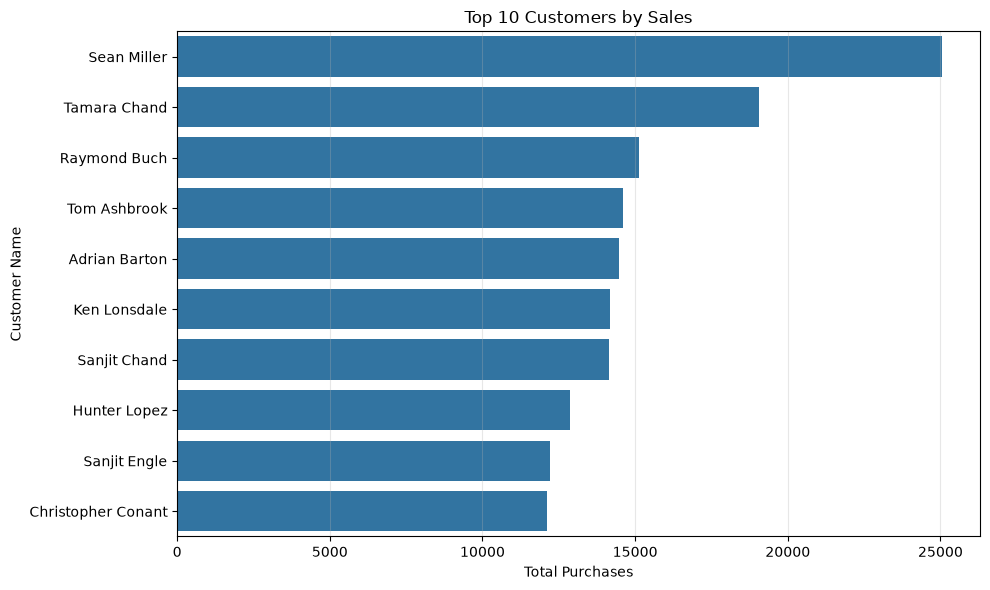

In [68]:
#Horizontal bar chart for top 10 customers by sales
plt.figure(figsize=(10, 6))
top_10_customers = top_customers.head(10)
plot = sns.barplot(x=top_10_customers.values, y=top_10_customers.index)
plt.title('Top 10 Customers by Sales')
plt.xlabel('Total Purchases')
plt.ylabel('Customer Name')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

##### Our top costumer is Sean Miller by spending 25043.050